# 05 — ML Classification: XGBoost & Random Forest


In [1]:
from google.colab import files
files.upload()

Saving gold_silver_final.csv to gold_silver_final.csv


{'gold_silver_final.csv': b'Date,ID_Column,usd_idx,gold,silver,interest,vix,au_returns,ag_returns,au_vol,ag_vol,au_mean,ag_mean,garch_vol_au,garch_vol_ag,vol_regime_au,vol_regime_ag,period_regime,au_lag1,ag_lag1,au_lag2,ag_lag2,au_lag5,ag_lag5,vix_chg,usd_chg,interest_chg,au_ag_ratio,au_ag_ratio_z,garch_vol_au_lag1,garch_vol_ag_lag1,target_au,target_ag\n2010-03-10,5,80.44999694824219,1107.800048828125,16.993999481201172,3.7200000286102295,18.56999969482422,-0.0127366964069781,-0.0188861587895096,0.0102574869504297,0.0176469712480621,0.0018449664888878,0.0056963608433109,0.0082720668889039,0.0136129091073042,low_vol,low_vol,pre_covid,-0.0014249874190179,0.0038183431802686,-0.0099186724609921,-0.0063557561838186,0.0050885588128825,0.0154283259825429,0.03627229998676995,-0.0017371807421538987,0.019000053405761275,65.18771817391061,-0.5787036281619229,0.008444740435278,0.0138647067821398,1,1\n2010-03-11,6,80.31999969482422,1108.0,17.13599967956543,3.7200000286102295,18.059999465942383,0.00

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 110

df = pd.read_csv('gold_silver_final.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df.sort_index(inplace=True)
df = df.replace([np.inf, -np.inf], np.nan).dropna()

print(f"Loaded: {df.shape}")

Loaded: (4087, 32)


In [3]:
FEATURES = [
    'au_returns', 'ag_returns',
    'au_vol', 'ag_vol', 'au_mean', 'ag_mean',
    'au_lag1', 'au_lag2', 'au_lag5',
    'ag_lag1', 'ag_lag2', 'ag_lag5',
    'vix', 'interest', 'usd_idx',
    'vix_chg', 'usd_chg', 'interest_chg',
    'garch_vol_au', 'garch_vol_ag',
    'garch_vol_au_lag1', 'garch_vol_ag_lag1',
    'au_ag_ratio_z'
]

In [4]:
def evaluate_clf(y_true, y_pred, name, asset):
    from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
    acc  = accuracy_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred, average='weighted')
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    print(f"\n  {name} — {asset}")
    print(f"    Accuracy  : {acc:.4f}")
    print(f"    F1        : {f1:.4f}")
    print(f"    Precision : {prec:.4f}")
    print(f"    Recall    : {rec:.4f}")
    return {"model": name, "asset": asset, "accuracy": acc, "f1": f1}

def regime_eval(results_df, model_name, asset, regime_col):
    from sklearn.metrics import accuracy_score, f1_score
    print(f"\n  {model_name} | {asset} | by {regime_col}")
    rows = []
    for regime in sorted(results_df[regime_col].unique()):
        sub = results_df[results_df[regime_col] == regime]
        if len(sub) < 10:
            continue
        acc = accuracy_score(sub['actual'], sub['pred'])
        f1  = f1_score(sub['actual'], sub['pred'], average='weighted', zero_division=0)
        print(f"    {regime:12s} | n={len(sub):4d} | Acc={acc:.4f} | F1={f1:.4f}")
        rows.append({"regime": regime, "n": len(sub), "accuracy": acc, "f1": f1})
    return rows

def run_backtest(results_df, return_col, model_name, asset):
    bt = results_df.copy()
    bt['signal']           = np.where(bt['pred'] == 1, 1, -1)
    bt['strat_ret']        = bt['signal'] * bt[return_col]
    bt['cum_strat']        = (1 + bt['strat_ret']).cumprod()
    bt['cum_bh']           = (1 + bt[return_col]).cumprod()
    total_strat = bt['cum_strat'].iloc[-1] - 1
    total_bh    = bt['cum_bh'].iloc[-1] - 1
    hit_rate    = (bt['signal'] == (bt[return_col] > 0).map({True:1, False:-1})).mean()

    plt.figure(figsize=(14, 5))
    bt['cum_strat'].plot(label=f'{model_name} L/S Strategy', linewidth=1.5)
    bt['cum_bh'].plot(label='Buy & Hold', linewidth=1.2, linestyle='--', alpha=0.8)
    plt.axhline(1, color='black', linewidth=0.6, alpha=0.4)
    plt.title(f'{model_name} — {asset} | Strategy: {total_strat:.1%}  vs  B&H: {total_bh:.1%}  | Hit Rate: {hit_rate:.1%}',
              fontweight='bold')
    plt.ylabel('Cumulative Return (₹1 Start)')
    plt.legend()
    plt.tight_layout()
    plt.show()

    return total_strat, total_bh, hit_rate


## 1. Train / Test Split

In [5]:
split_idx = int(len(df) * 0.70)
train = df.iloc[:split_idx]
test  = df.iloc[split_idx:]

X_train = train[FEATURES]
X_test  = test[FEATURES]

print(f"Train: {train.index[0].date()} → {train.index[-1].date()} ({len(train)} rows)")
print(f"Test : {test.index[0].date()} → {test.index[-1].date()} ({len(test)} rows)")

Train: 2010-03-10 → 2021-07-23 (2860 rows)
Test : 2021-07-26 → 2026-06-12 (1227 rows)


## 2. XGBoost Classifier

In [6]:
xgb_au = XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.03,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=1, use_label_encoder=False,
    eval_metric='logloss', random_state=42, n_jobs=-1
)
xgb_ag = XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.03,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=1, use_label_encoder=False,
    eval_metric='logloss', random_state=42, n_jobs=-1
)

xgb_au.fit(X_train, train['target_au'], eval_set=[(X_test, test['target_au'])], verbose=False)
xgb_ag.fit(X_train, train['target_ag'], eval_set=[(X_test, test['target_ag'])], verbose=False)

pred_xgb_au      = xgb_au.predict(X_test)
pred_xgb_au_prob = xgb_au.predict_proba(X_test)[:, 1]
pred_xgb_ag      = xgb_ag.predict(X_test)
pred_xgb_ag_prob = xgb_ag.predict_proba(X_test)[:, 1]

print("=== XGBoost — GOLD ===")
print(classification_report(test['target_au'], pred_xgb_au, target_names=['DOWN','UP']))
print("=== XGBoost — SILVER ===")
print(classification_report(test['target_ag'], pred_xgb_ag, target_names=['DOWN','UP']))

=== XGBoost — GOLD ===
              precision    recall  f1-score   support

        DOWN       0.50      0.22      0.31       556
          UP       0.56      0.81      0.66       671

    accuracy                           0.55      1227
   macro avg       0.53      0.52      0.49      1227
weighted avg       0.53      0.55      0.50      1227

=== XGBoost — SILVER ===
              precision    recall  f1-score   support

        DOWN       0.48      0.15      0.22       584
          UP       0.53      0.86      0.65       643

    accuracy                           0.52      1227
   macro avg       0.50      0.50      0.44      1227
weighted avg       0.51      0.52      0.45      1227



## 3. Random Forest Classifier

In [7]:
rf_au = RandomForestClassifier(
    n_estimators=300, max_depth=6, min_samples_leaf=10,
    class_weight='balanced', random_state=42, n_jobs=-1
)
rf_ag = RandomForestClassifier(
    n_estimators=300, max_depth=6, min_samples_leaf=10,
    class_weight='balanced', random_state=42, n_jobs=-1
)

rf_au.fit(X_train, train['target_au'])
rf_ag.fit(X_train, train['target_ag'])

pred_rf_au      = rf_au.predict(X_test)
pred_rf_au_prob = rf_au.predict_proba(X_test)[:, 1]
pred_rf_ag      = rf_ag.predict(X_test)
pred_rf_ag_prob = rf_ag.predict_proba(X_test)[:, 1]

print("=== Random Forest — GOLD ===")
print(classification_report(test['target_au'], pred_rf_au, target_names=['DOWN','UP']))
print("=== Random Forest — SILVER ===")
print(classification_report(test['target_ag'], pred_rf_ag, target_names=['DOWN','UP']))

=== Random Forest — GOLD ===
              precision    recall  f1-score   support

        DOWN       0.53      0.22      0.31       556
          UP       0.57      0.84      0.68       671

    accuracy                           0.56      1227
   macro avg       0.55      0.53      0.50      1227
weighted avg       0.55      0.56      0.51      1227

=== Random Forest — SILVER ===
              precision    recall  f1-score   support

        DOWN       0.53      0.25      0.34       584
          UP       0.54      0.80      0.64       643

    accuracy                           0.54      1227
   macro avg       0.54      0.52      0.49      1227
weighted avg       0.54      0.54      0.50      1227



## 4. Confusion Matrices

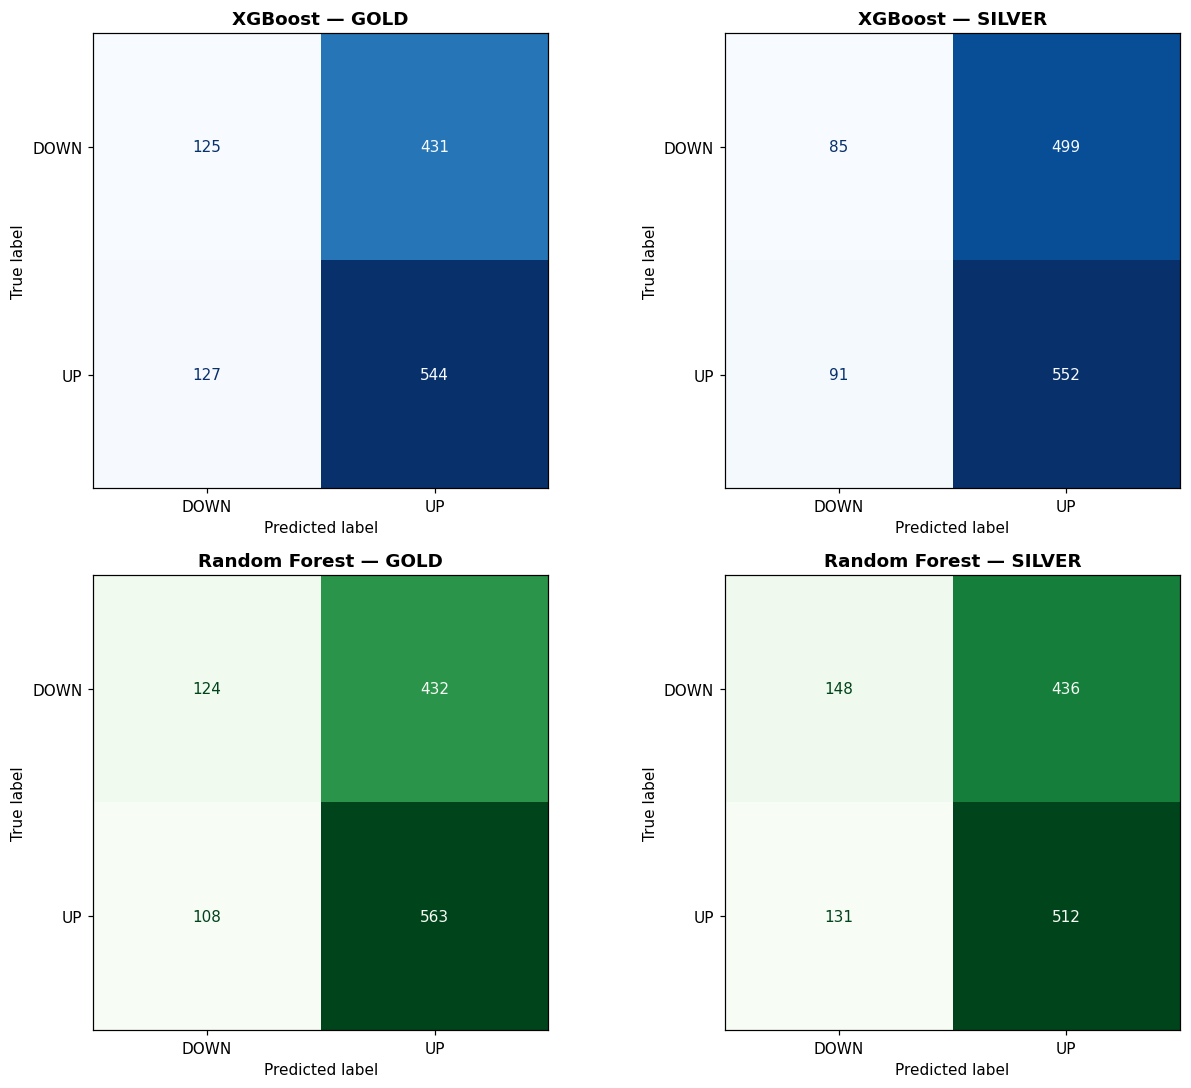

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
pairs = [
    (test['target_au'], pred_xgb_au, 'XGBoost — GOLD',   'Blues',  axes[0,0]),
    (test['target_ag'], pred_xgb_ag, 'XGBoost — SILVER', 'Blues',  axes[0,1]),
    (test['target_au'], pred_rf_au,  'Random Forest — GOLD',   'Greens', axes[1,0]),
    (test['target_ag'], pred_rf_ag,  'Random Forest — SILVER', 'Greens', axes[1,1]),
]
for y_true, y_pred, title, cmap, ax in pairs:
    ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred),
                           display_labels=['DOWN','UP']).plot(cmap=cmap, ax=ax, colorbar=False)
    ax.set_title(title, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Feature Importance

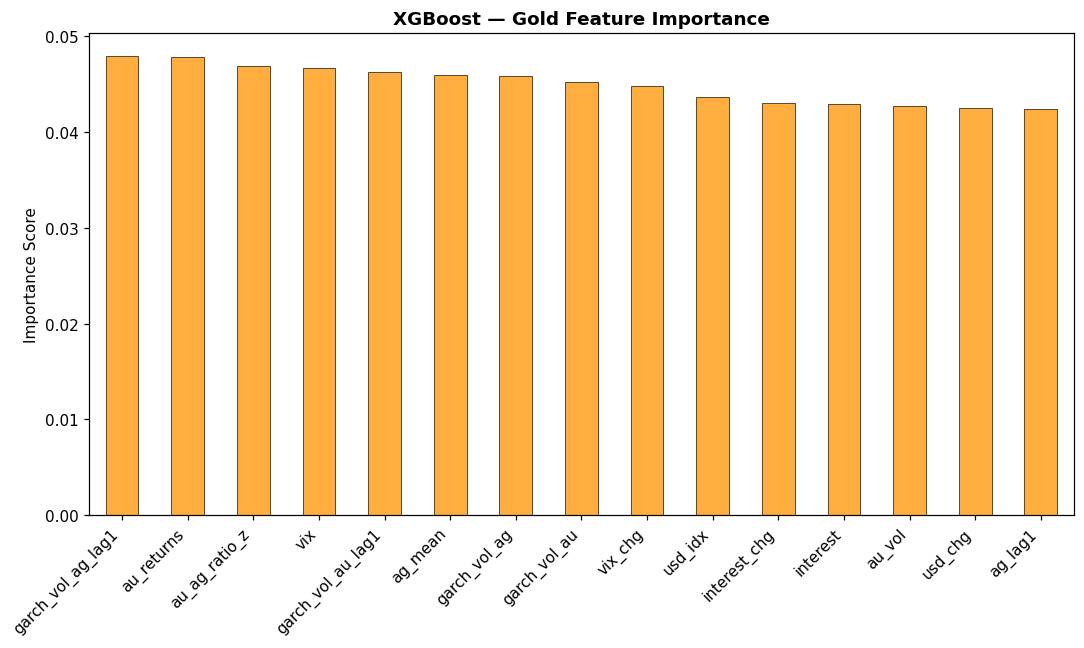

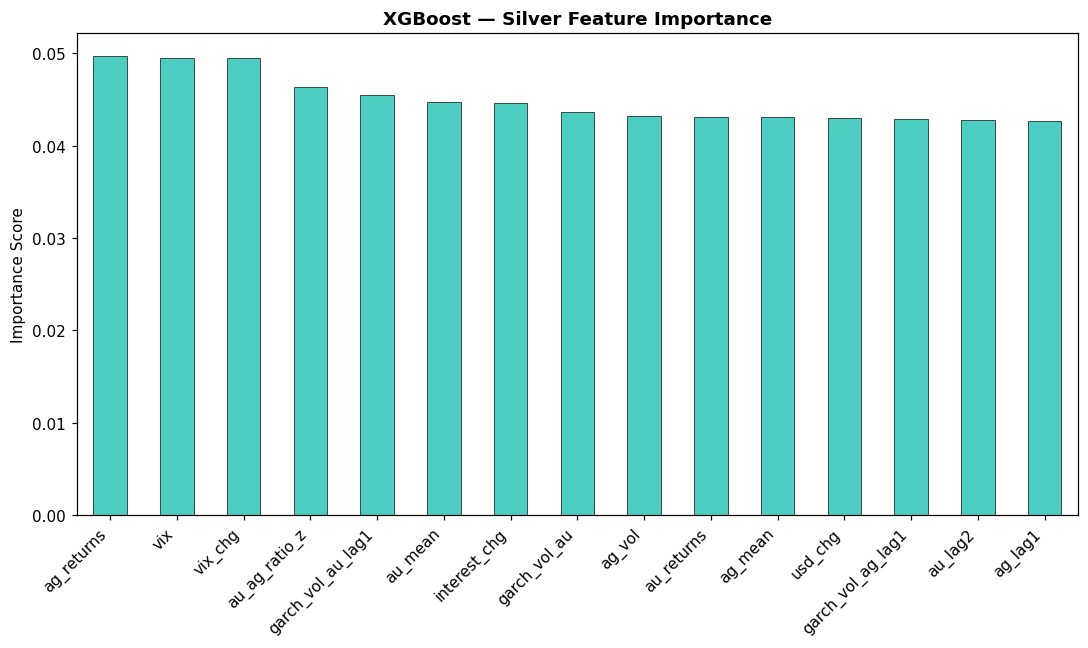

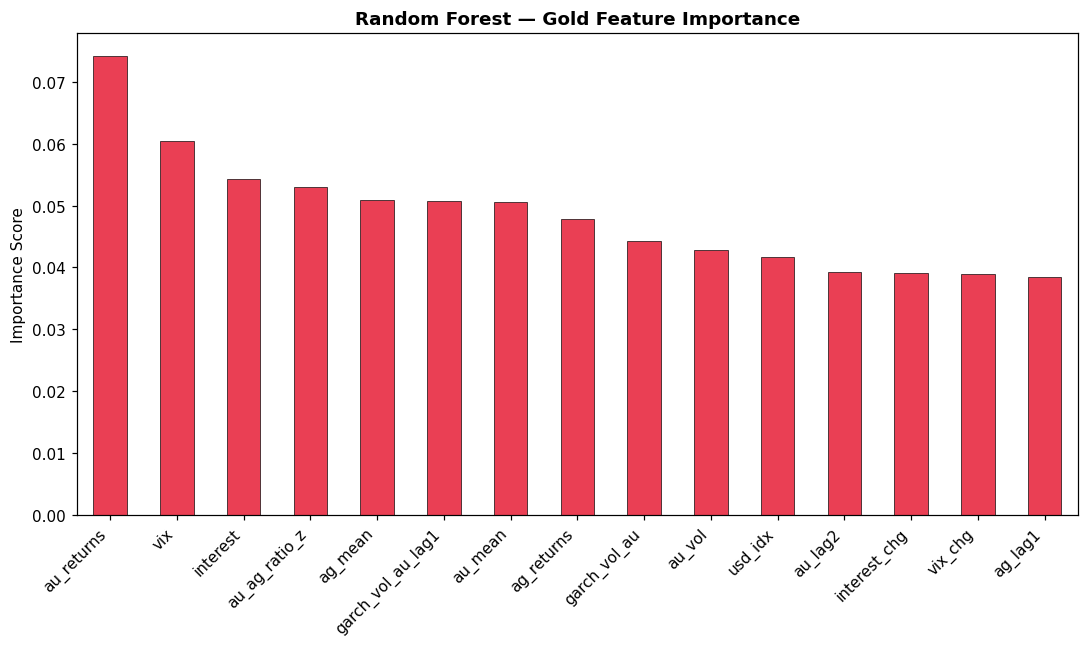

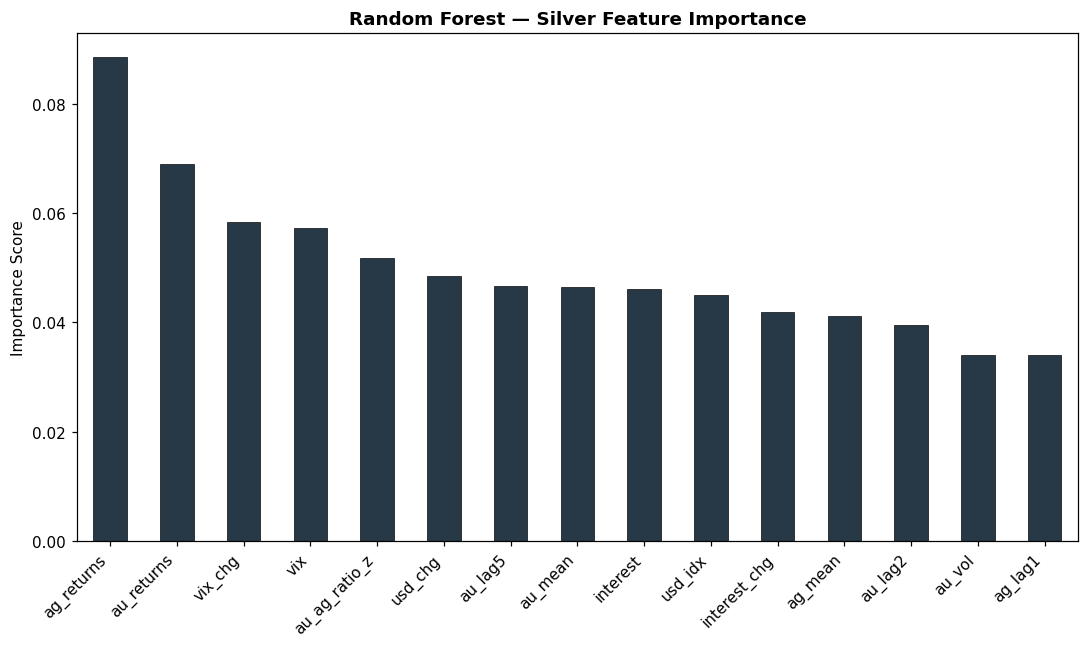

In [9]:
def plot_importance(model, feature_names, title, color):
    imp = pd.Series(model.feature_importances_, index=feature_names).sort_values(ascending=False)
    plt.figure(figsize=(10, 6))
    imp.head(15).plot(kind='bar', color=color, alpha=0.85, edgecolor='black', linewidth=0.5)
    plt.title(title, fontweight='bold')
    plt.ylabel('Importance Score')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

plot_importance(xgb_au, FEATURES, 'XGBoost — Gold Feature Importance',          '#FF9F1C')
plot_importance(xgb_ag, FEATURES, 'XGBoost — Silver Feature Importance',        '#2EC4B6')
plot_importance(rf_au,  FEATURES, 'Random Forest — Gold Feature Importance',    '#E71D36')
plot_importance(rf_ag,  FEATURES, 'Random Forest — Silver Feature Importance',  '#011627')

## 6. Regime-Wise Evaluation

In [10]:
def build_results(actual, pred, prob, returns, vol_regime, period_regime, index):
    return pd.DataFrame({
        'actual': actual, 'pred': pred, 'prob': prob,
        'returns': returns, 'vol_regime': vol_regime, 'period_regime': period_regime
    }, index=index)

res_xgb_au = build_results(test['target_au'], pred_xgb_au, pred_xgb_au_prob,
                            test['au_returns'], test['vol_regime_au'], test['period_regime'], test.index)
res_xgb_ag = build_results(test['target_ag'], pred_xgb_ag, pred_xgb_ag_prob,
                            test['ag_returns'], test['vol_regime_ag'], test['period_regime'], test.index)
res_rf_au  = build_results(test['target_au'], pred_rf_au, pred_rf_au_prob,
                            test['au_returns'], test['vol_regime_au'], test['period_regime'], test.index)
res_rf_ag  = build_results(test['target_ag'], pred_rf_ag, pred_rf_ag_prob,
                            test['ag_returns'], test['vol_regime_ag'], test['period_regime'], test.index)

for res, name, asset in [
    (res_xgb_au, 'XGBoost',       'GOLD'),
    (res_xgb_ag, 'XGBoost',       'SILVER'),
    (res_rf_au,  'Random Forest', 'GOLD'),
    (res_rf_ag,  'Random Forest', 'SILVER'),
]:
    regime_eval(res, name, asset, 'vol_regime')
    regime_eval(res, name, asset, 'period_regime')


  XGBoost | GOLD | by vol_regime
    high_vol     | n= 719 | Acc=0.5716 | F1=0.5419
    low_vol      | n= 508 | Acc=0.5079 | F1=0.4399

  XGBoost | GOLD | by period_regime
    covid        | n= 112 | Acc=0.5446 | F1=0.5423
    post_covid   | n=1115 | Acc=0.5453 | F1=0.4878

  XGBoost | SILVER | by vol_regime
    high_vol     | n= 718 | Acc=0.5181 | F1=0.4523
    low_vol      | n= 509 | Acc=0.5206 | F1=0.4417

  XGBoost | SILVER | by period_regime
    covid        | n= 112 | Acc=0.5179 | F1=0.5146
    post_covid   | n=1115 | Acc=0.5193 | F1=0.4346

  Random Forest | GOLD | by vol_regime
    high_vol     | n= 719 | Acc=0.5869 | F1=0.5533
    low_vol      | n= 508 | Acc=0.5217 | F1=0.4493

  Random Forest | GOLD | by period_regime
    covid        | n= 112 | Acc=0.5714 | F1=0.5631
    post_covid   | n=1115 | Acc=0.5587 | F1=0.4929

  Random Forest | SILVER | by vol_regime
    high_vol     | n= 718 | Acc=0.5460 | F1=0.5214
    low_vol      | n= 509 | Acc=0.5265 | F1=0.4654

  Random Fores

## 7. Backtest


=== XGBoost Backtest ===


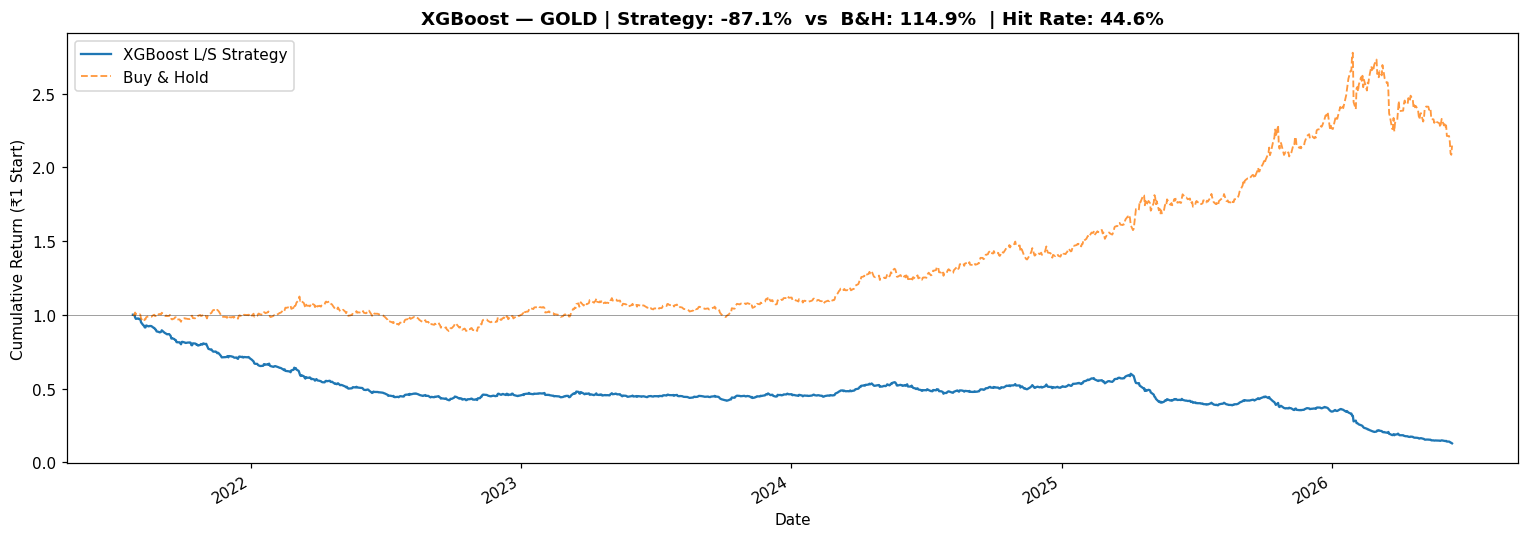

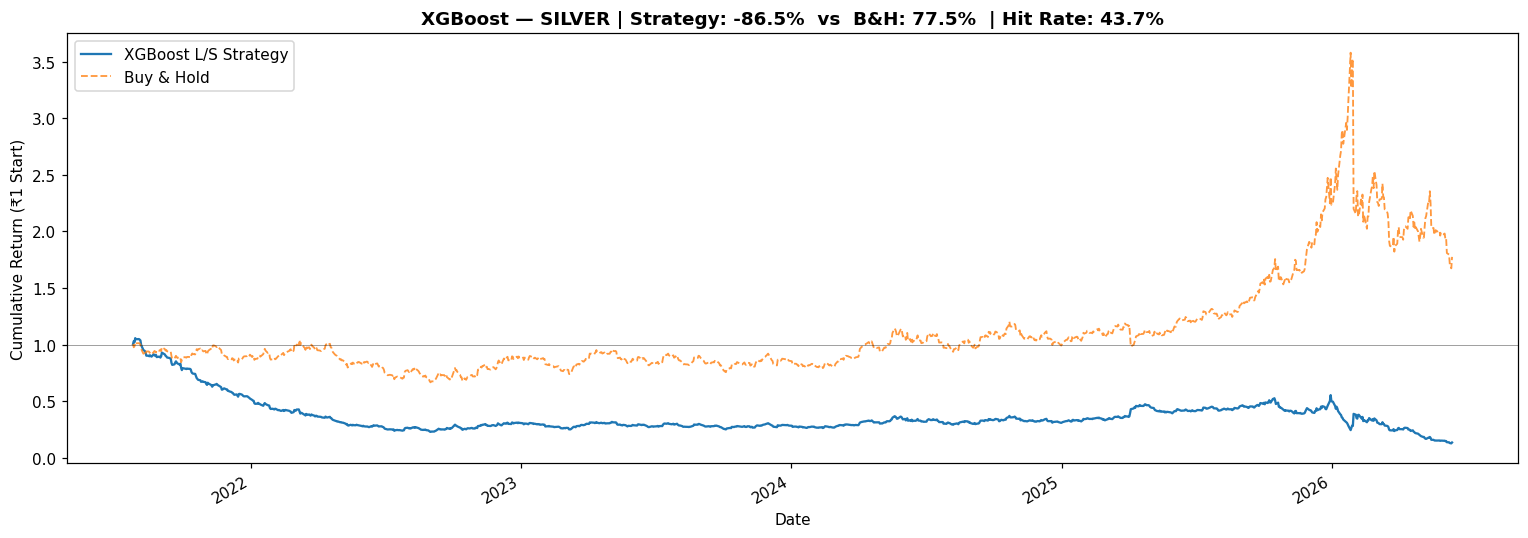


=== Random Forest Backtest ===


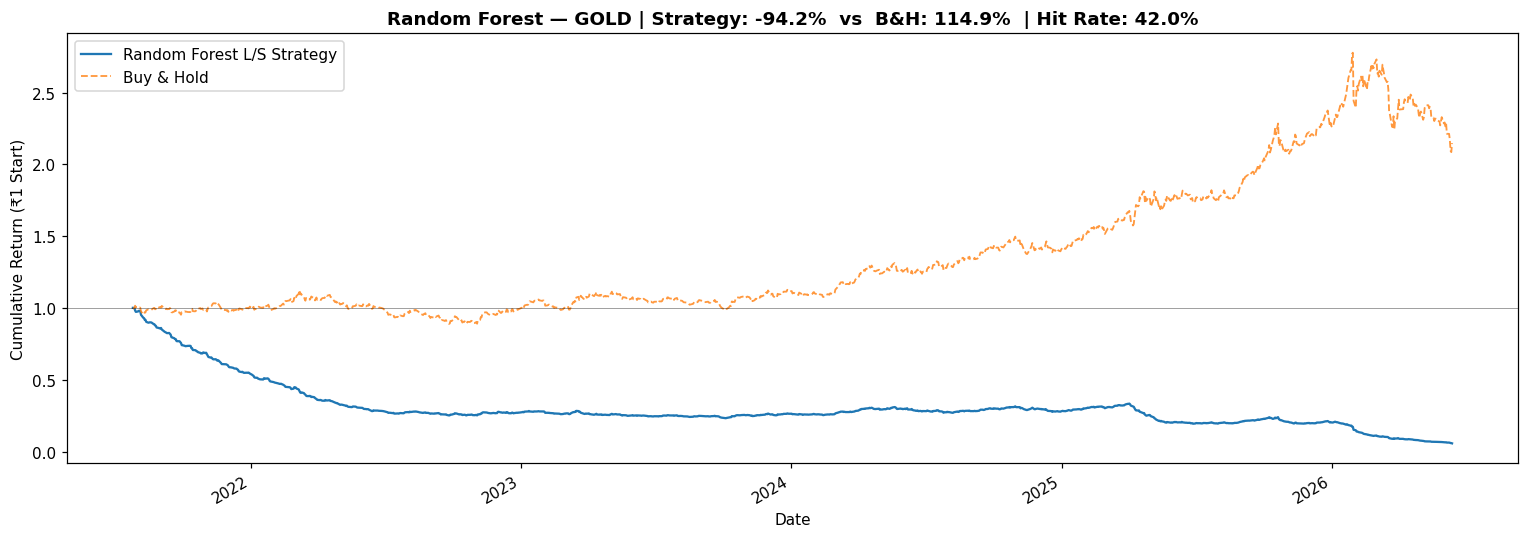

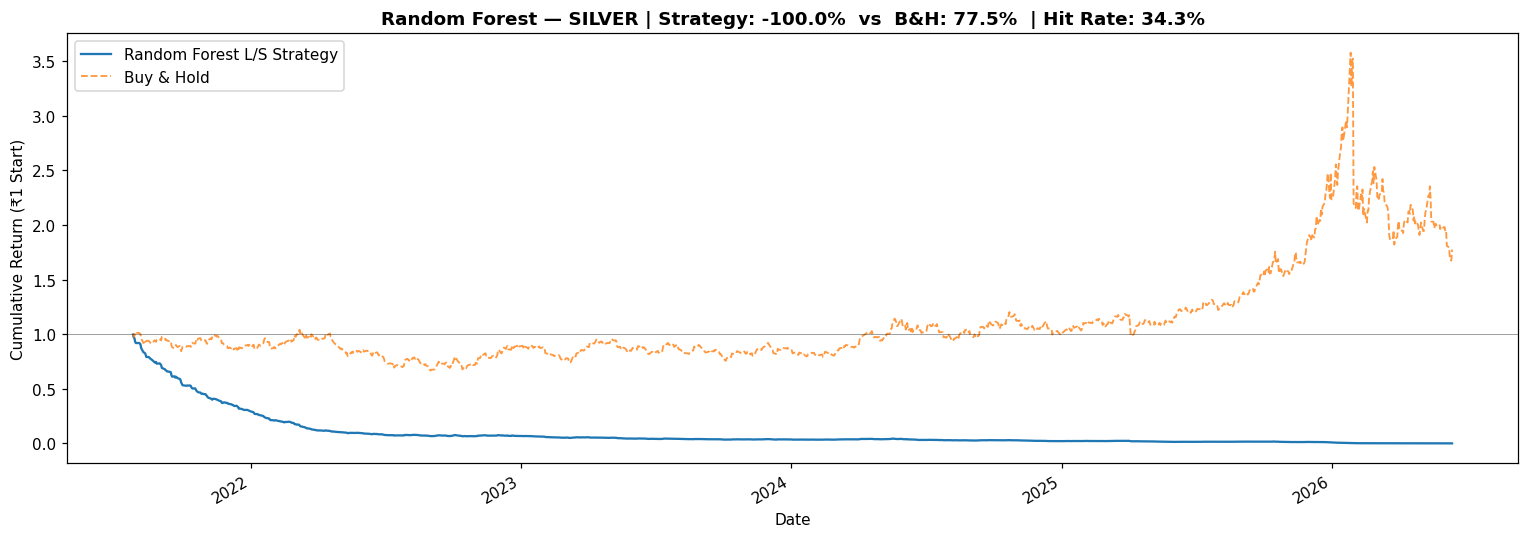

(np.float64(-0.9998404588884853),
 np.float64(0.7747004963275068),
 np.float64(0.34311328443357786))

In [11]:
print("\n=== XGBoost Backtest ===")
run_backtest(res_xgb_au, 'returns', 'XGBoost', 'GOLD')
run_backtest(res_xgb_ag, 'returns', 'XGBoost', 'SILVER')

print("\n=== Random Forest Backtest ===")
run_backtest(res_rf_au, 'returns', 'Random Forest', 'GOLD')
run_backtest(res_rf_ag, 'returns', 'Random Forest', 'SILVER')

## 8. Save Predictions

In [12]:
res_xgb_au.to_csv('preds_xgb_au.csv')
res_xgb_ag.to_csv('preds_xgb_ag.csv')
res_rf_au.to_csv('preds_rf_au.csv')
res_rf_ag.to_csv('preds_rf_ag.csv')
print("Saved all ML prediction CSVs.")

Saved all ML prediction CSVs.


In [13]:
files.download('preds_xgb_au.csv')
files.download('preds_xgb_ag.csv')
files.download('preds_rf_au.csv')
files.download('preds_rf_ag.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>